In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

In [2]:
def normalizar_amostra(amostra, n, mi, sigma2):
    normal = np.sqrt(n)*(np.mean(amostra,axis=1)-mi)/np.sqrt(sigma2)
    return normal

### Uniforme


In [3]:
n = 1000
M = 5000

In [4]:
amostras_uniformes = np.random.uniform(size=(M,n))
amostra_normalizada = normalizar_amostra(amostras_uniformes, n, 0.5, 1/12)

(array([  22.,   87.,  337.,  824., 1246., 1315.,  774.,  301.,   79.,
          15.]),
 array([-3.4402082 , -2.74441833, -2.04862846, -1.35283859, -0.65704872,
         0.03874115,  0.73453102,  1.43032089,  2.12611076,  2.82190063,
         3.5176905 ]),
 <BarContainer object of 10 artists>)

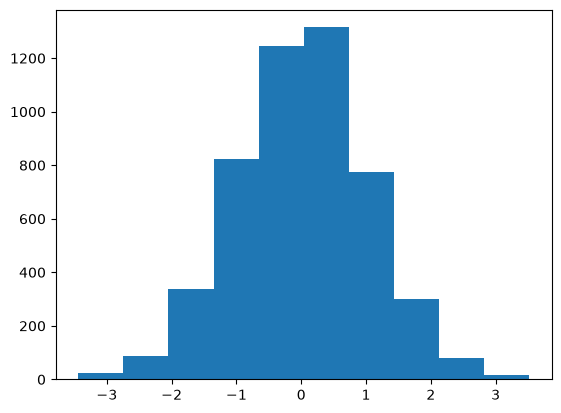

In [5]:
plt.hist(amostra_normalizada)

### Bernoulli

In [6]:
p = 0.5

amostra_bernoulli = amostras_uniformes < p

In [7]:
amostra_normalizada_bernoullis = normalizar_amostra(amostra_bernoulli, n, 0.5, 0.25)

(array([   3.,   31.,  164.,  702., 1299., 1523.,  880.,  325.,   66.,
           7.]),
 array([-4.11096096, -3.32039154, -2.52982213, -1.73925271, -0.9486833 ,
        -0.15811388,  0.63245553,  1.42302495,  2.21359436,  3.00416378,
         3.79473319]),
 <BarContainer object of 10 artists>)

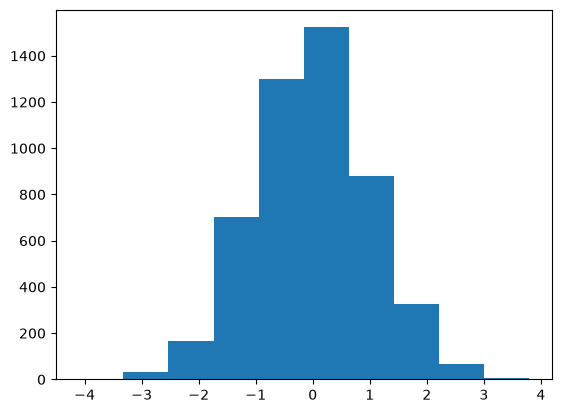

In [8]:
plt.hist(amostra_normalizada_bernoullis)

### Geométrica

In [9]:
p = 0.5
amostras_geometricas = np.floor(np.log(1-amostras_uniformes)/np.log(1-p)) + 1


In [12]:
amostras_geometricas_normalizadas = normalizar_amostra(amostras_geometricas, n, 2, 2)

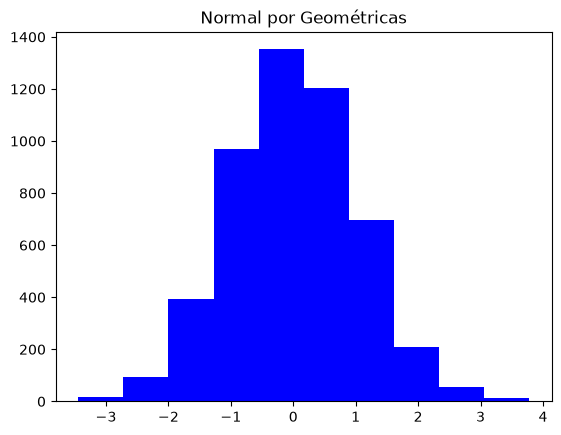

In [19]:
plt.hist(amostras_geometricas_normalizadas, color="blue")
plt.title("Normal por Geométricas")
plt.show()

### Poisson

In [54]:
lmbd = 5
amostra_1_poisson = []
for i in range(n):
    u = np.random.uniform()
    i = 0
    p0 = np.exp(-lmbd)
    F = p0
    while u > F:
        i += 1
        p0 *= (lmbd/i)
        F += p0
    amostra_1_poisson.append(i)


In [55]:
print(amostra_1_poisson)

[6, 6, 4, 2, 1, 2, 5, 4, 3, 5, 8, 5, 2, 4, 3, 4, 6, 6, 3, 5, 5, 4, 7, 8, 5, 6, 5, 8, 6, 7, 4, 5, 4, 1, 5, 4, 7, 2, 9, 6, 3, 4, 3, 7, 8, 10, 8, 3, 4, 7, 4, 4, 8, 6, 6, 11, 5, 5, 8, 5, 2, 5, 1, 7, 4, 4, 3, 5, 7, 9, 6, 4, 6, 4, 4, 9, 7, 5, 6, 4, 5, 3, 5, 6, 1, 4, 3, 6, 7, 5, 4, 5, 7, 9, 6, 8, 2, 1, 4, 4, 5, 4, 9, 2, 2, 7, 2, 5, 6, 5, 6, 3, 5, 4, 7, 4, 3, 4, 6, 4, 6, 1, 5, 3, 3, 2, 8, 9, 3, 3, 6, 3, 4, 6, 3, 4, 5, 6, 10, 5, 1, 3, 2, 4, 4, 11, 6, 1, 8, 4, 7, 1, 4, 4, 2, 5, 7, 7, 3, 7, 7, 4, 7, 4, 5, 3, 4, 2, 1, 3, 4, 4, 7, 7, 2, 2, 2, 6, 7, 4, 6, 7, 3, 5, 6, 5, 4, 3, 5, 8, 6, 7, 4, 5, 1, 4, 2, 0, 5, 7, 2, 3, 6, 9, 6, 4, 3, 10, 7, 6, 4, 5, 8, 7, 3, 2, 4, 7, 2, 6, 5, 5, 4, 7, 4, 9, 4, 5, 7, 7, 7, 6, 1, 5, 7, 5, 2, 4, 3, 1, 9, 1, 3, 0, 9, 2, 5, 6, 7, 6, 2, 5, 5, 7, 5, 2, 5, 9, 2, 7, 8, 9, 4, 3, 4, 6, 4, 8, 3, 5, 7, 1, 2, 3, 9, 6, 4, 6, 7, 5, 4, 2, 5, 4, 5, 4, 3, 3, 2, 8, 2, 7, 8, 4, 4, 7, 4, 6, 2, 1, 4, 3, 5, 4, 3, 4, 7, 3, 5, 4, 4, 4, 5, 3, 5, 2, 5, 5, 7, 1, 11, 3, 6, 4, 4, 4, 6, 2, 5, 4, 6, 

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.